# 03 - Exploratory Data Analysis

## Customer Intelligence Platform

---
This notebook conducts extensive exploratory data analysis across five dimensions:
1. **Churn Distribution** - Overall patterns
2. **Demographics** - Who churns?
3. **Services** - Which services affect retention?
4. **Contracts & Payment** - Which agreements are risky?
5. **Financial** - Does spending influence churn?
6. **Tenure** - When do customers leave?
7. **Geographic** - Where are churn hotspots?

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# imports from self defined module
from src.load_data import load_clean, load_raw_with_geo_and_target
from src.config import TARGET, DEMOGRAPHIC_FEATURES, SERVICE_FEATURES, ACCOUNT_FEATURES
# from src.eda import (
#     plot_churn_distribution,
#     plot_categorical_vs_churn,
#     plot_numerical_distribution,
#     plot_service_analysis,
#     plot_contract_analysis,
#     plot_financial_analysis,
#     plot_tenure_analysis,
#     plot_geographic_churn,
#     plot_correlation_heatmap,
# )
from src.eda import *

%matplotlib inline
plt.rcParams['figure.dpi'] = 100


In [2]:
df = load_clean()
df_raw = load_raw_with_geo_and_target()


✅ Loaded clean data: 7,043 rows × 20 cols
✅ Loaded raw data: 7,043 rows × 33 cols


## Overall Churn Distribution

---
**Business Question**: What is our baseline churn rate?


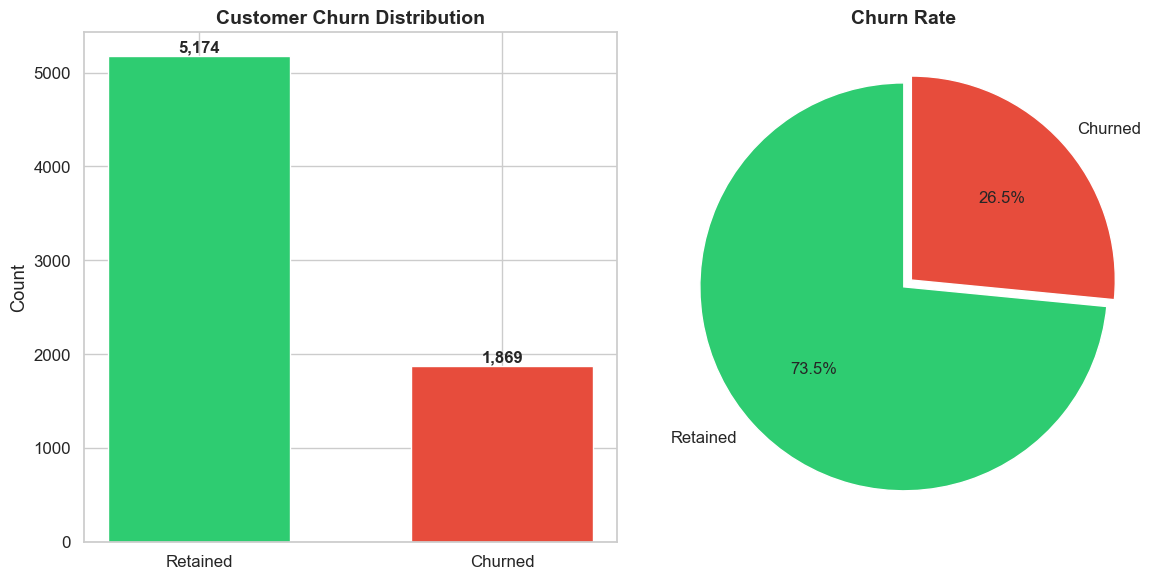

Total Customers: 7,043
Churned: 1,869
Retained: 5,174
Churn Rate: 26.54%


In [3]:
fig = plot_churn_distribution(df)
plt.show()

print(f"Total Customers: {len(df):,}")
print(f"Churned: {df[TARGET].sum():,}")
print(f"Retained: {(df[TARGET] == 0).sum():,}")
print(f"Churn Rate: {df[TARGET].mean():.2%}")


**Business Interpretation**: 
- Approximately 1 in 4 customers is churning.  
- At this rate, the company loses significant recurring revenue.  
- Retention-focused interventions could generate substantial business value.  

## Demographic Analysis

---
**Business Question**: Which demographic groups churn most?

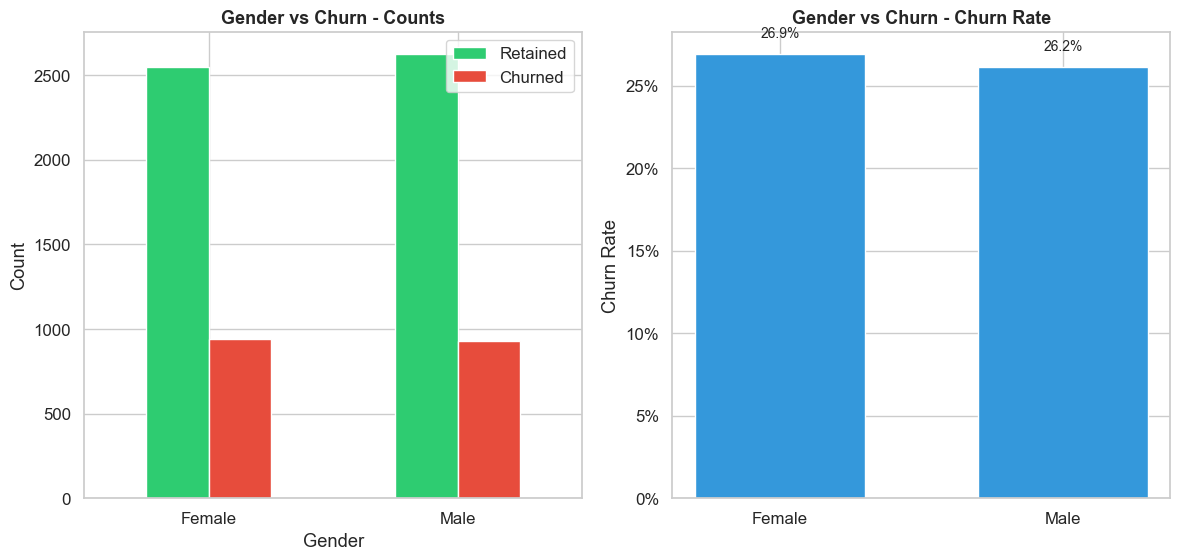


Gender Churn Rates:
Gender
Female    0.269209
Male      0.261603



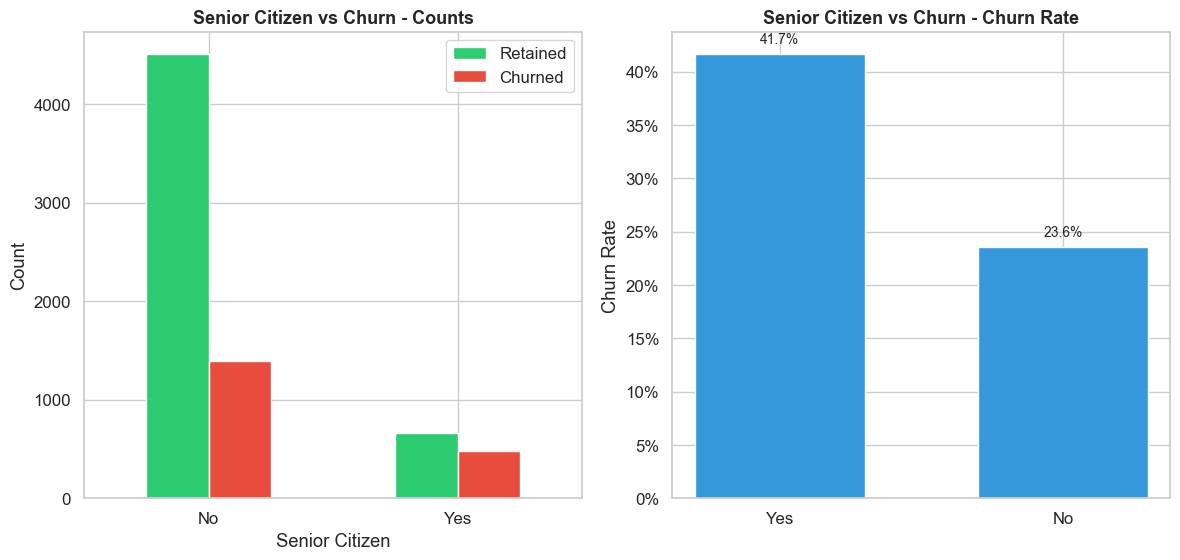


Senior Citizen Churn Rates:
Senior Citizen
Yes    0.416813
No     0.236062



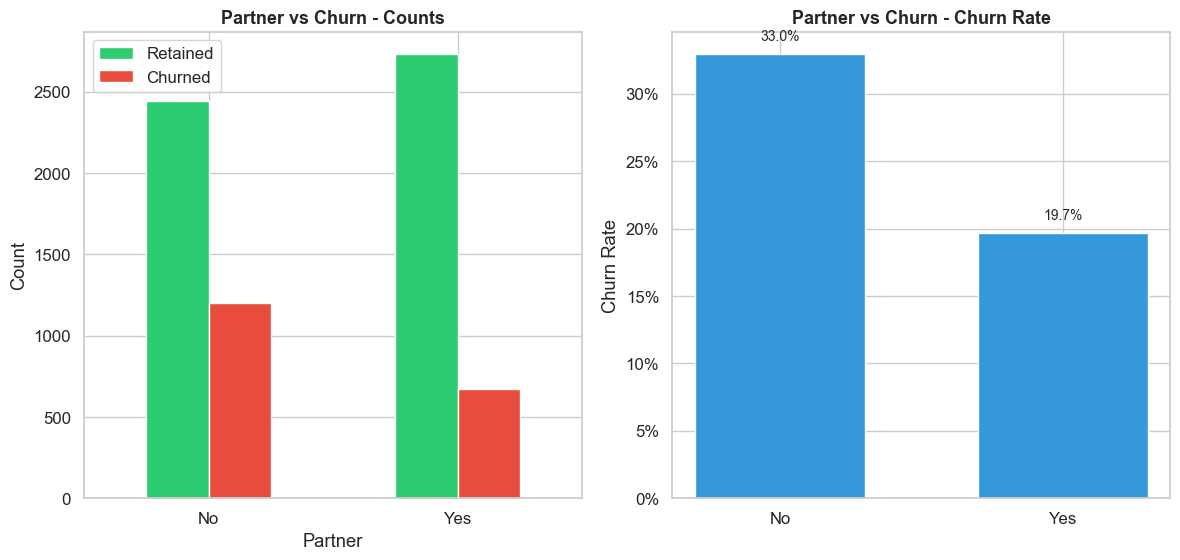


Partner Churn Rates:
Partner
No     0.329580
Yes    0.196649



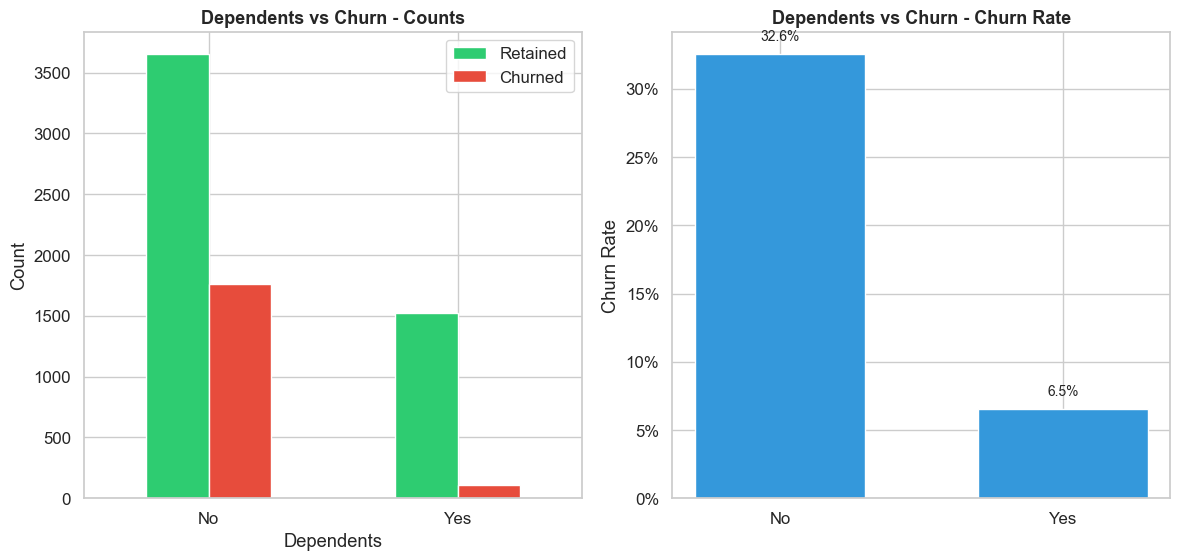


Dependents Churn Rates:
Dependents
No     0.325517
Yes    0.065151



In [4]:
for feat in DEMOGRAPHIC_FEATURES:
    fig = plot_categorical_vs_churn(df, feat)
    plt.show()
    print(f"\n{feat} Churn Rates:")
    print(df.groupby(feat)[TARGET].mean().sort_values(ascending=False).to_string())
    print()


### Demographic Findings

| Variable | Key Insight |
|----------|-------------|
| **Gender** | No significant difference. Gender is not a churn predictor. |
| **Senior Citizen** | Seniors churn at ~42% vs ~24% for non-seniors. Strong signal. |
| **Partner** | Customers with partners churn less (~20% vs ~33%). |
| **Dependents** | Strongest demographic signal. Customers with dependents: ~15% churn vs ~31%. |

**Key Takeaway**:   
	Family-oriented customers (with partners and dependents) are substantially more stable.

## Service Analysis

---
**Business Question**: Which services improve retention?

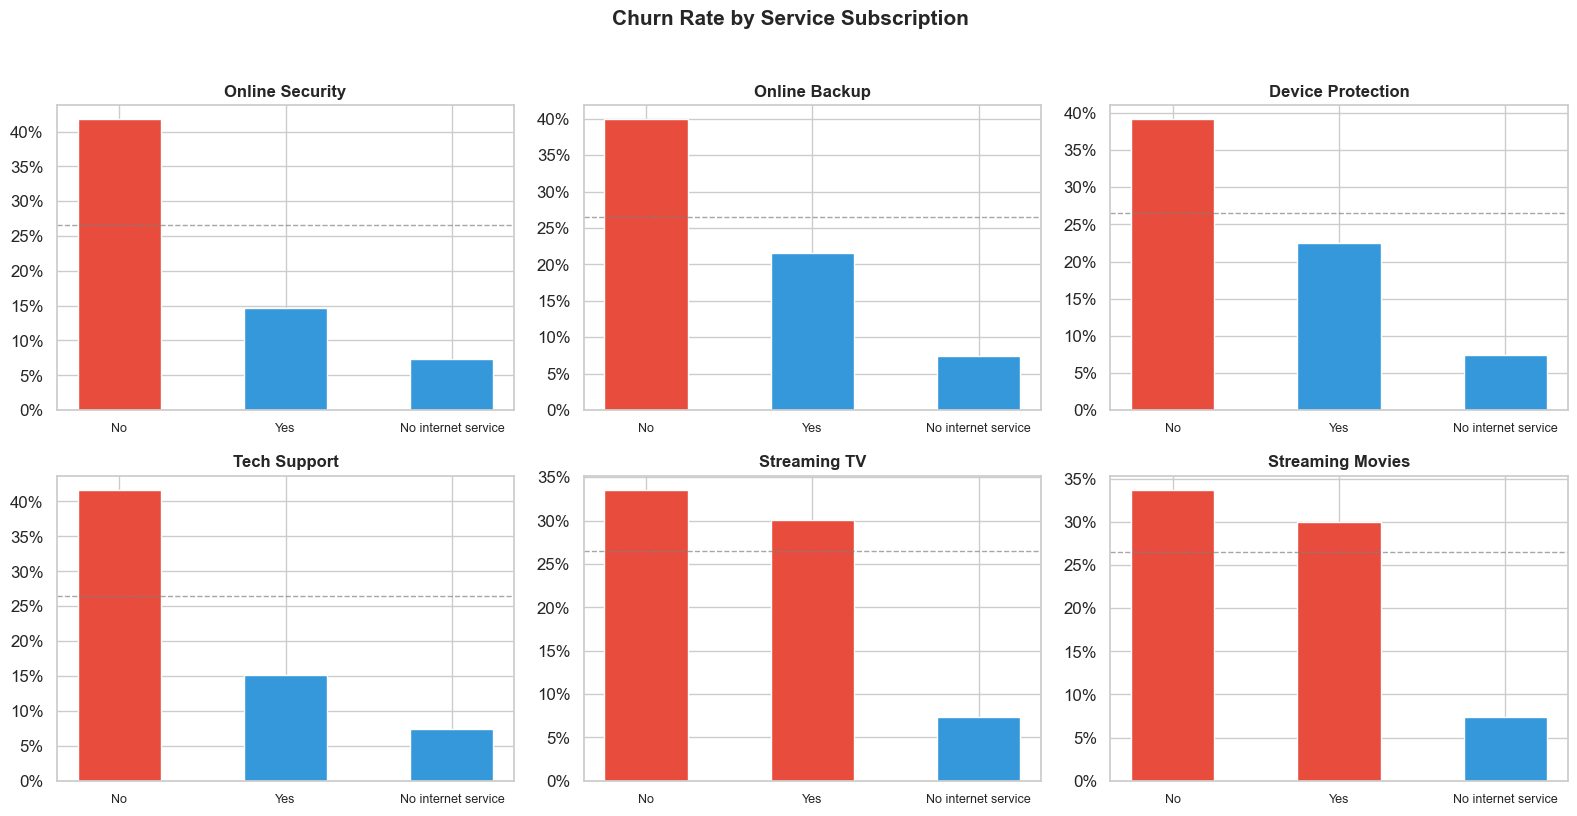

In [5]:
fig = plot_service_analysis(df)
plt.show()

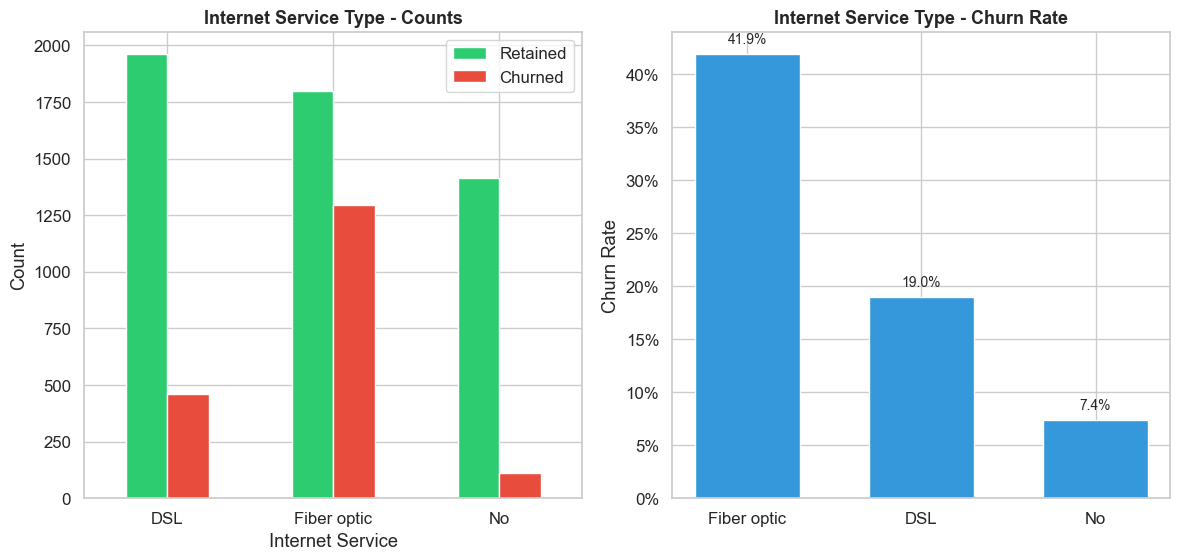

In [6]:
# Internet service type is critical
fig = plot_categorical_vs_churn(df, "Internet Service", title="Internet Service Type")
plt.show()

### Service Findings

| Service | Impact on Churn |
|---------|----------------|
| **Fiber Optic** | Highest churn (~42%). Possible quality/price dissatisfaction. |
| **Online Security** | Strong retention effect. Subscribers churn ~15% vs ~42% without. |
| **Tech Support** | Similar pattern. Subscribers churn ~15% vs ~42% without. |
| **Online Backup** | Moderate retention benefit. |
| **Device Protection** | Moderate retention benefit. |
| **Streaming** | Neutral effect. Entertainment services don't significantly influence churn. |

**Key Takeaway**:  
	 Security and support services are retention anchors. Fiber customers without these services are the highest-risk group.


## Contract & Payment Analysis

---
**Business Question**: Which customer agreements are risky?

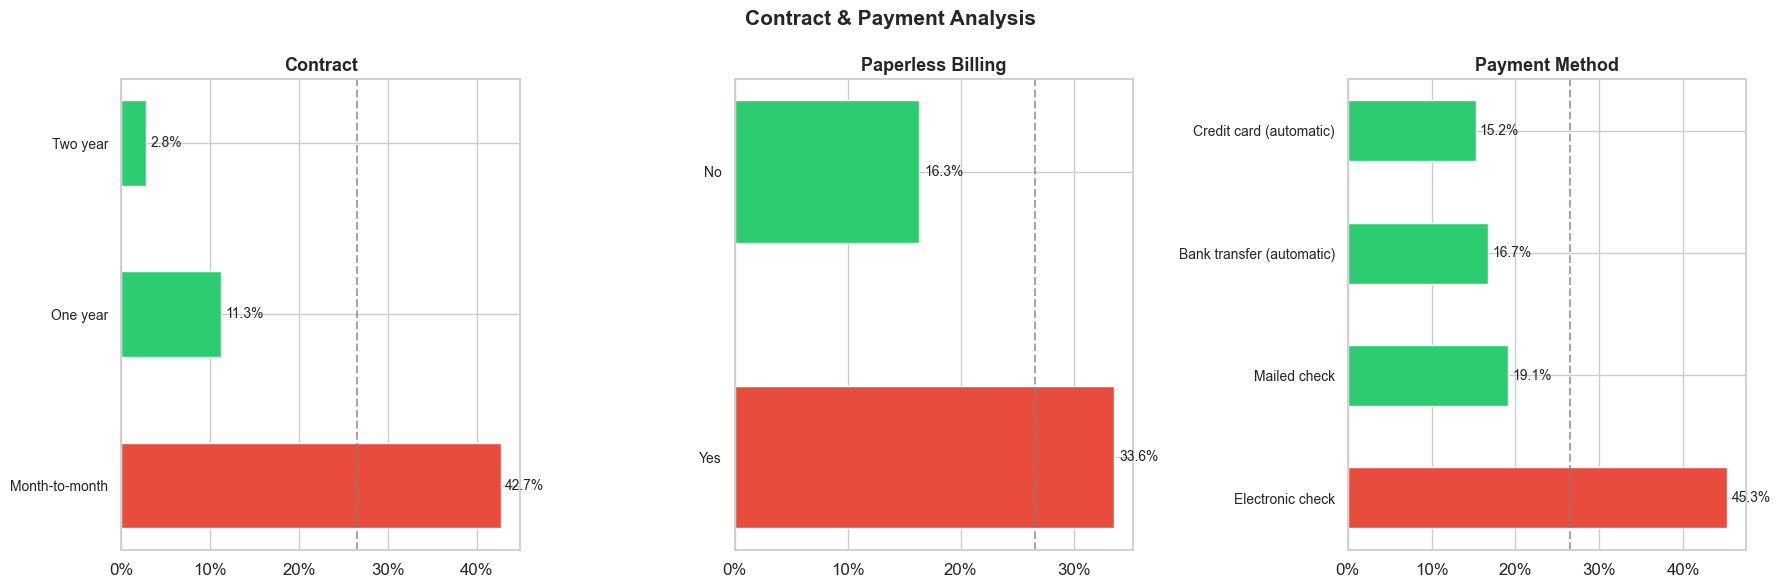

In [7]:
fig = plot_contract_analysis(df)
plt.show()

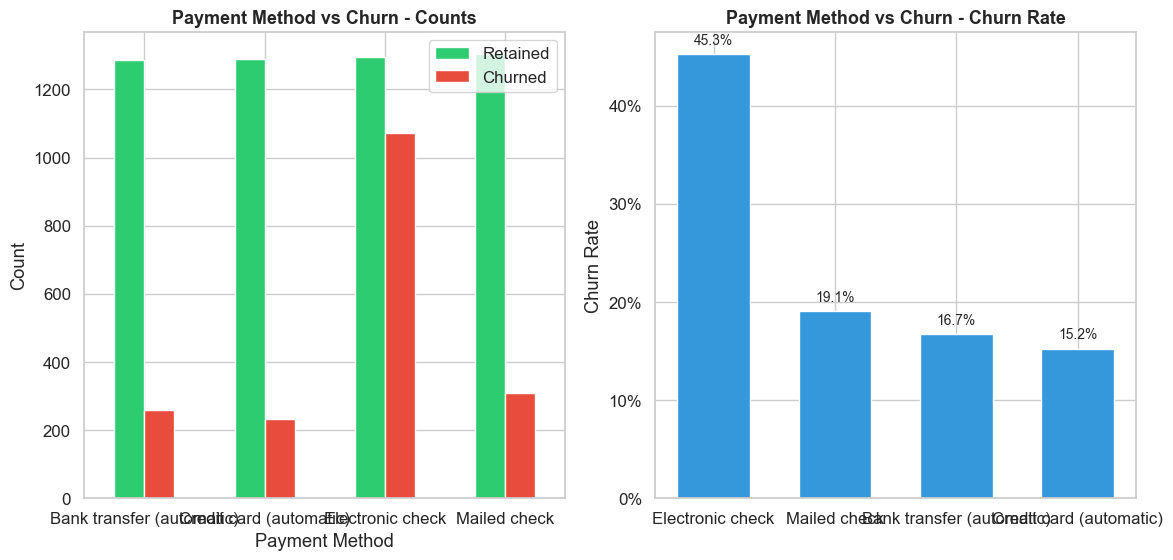

In [8]:
fig = plot_categorical_vs_churn(df, "Payment Method")
plt.show()

### Contract Findings

| Factor | Churn Rate |
|--------|-----------|
| **Month-to-Month** | ~43% (highest risk) |
| **One Year** | ~11% |
| **Two Year** | ~3% (lowest risk) |
| **Electronic Check** | ~45% (highest payment risk) |
| **Paperless Billing** | Higher churn than paper billing |

**Key Takeaway**: 
	Month-to-month contracts with electronic check payments represent the highest risk combination.

## Financial Analysis

---
**Business Question**: Does spending influence churn?

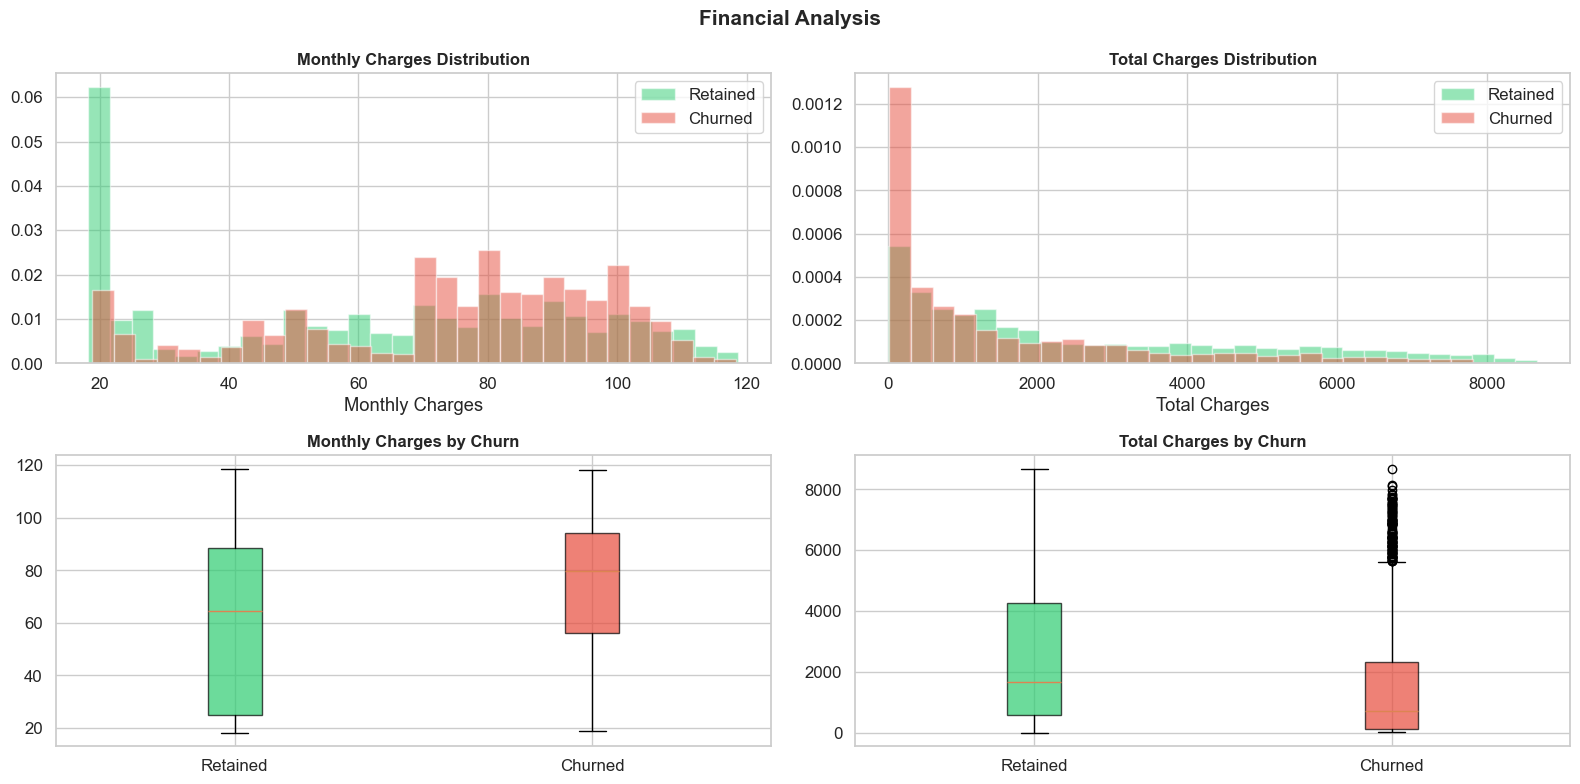

In [9]:
fig = plot_financial_analysis(df)
plt.show()

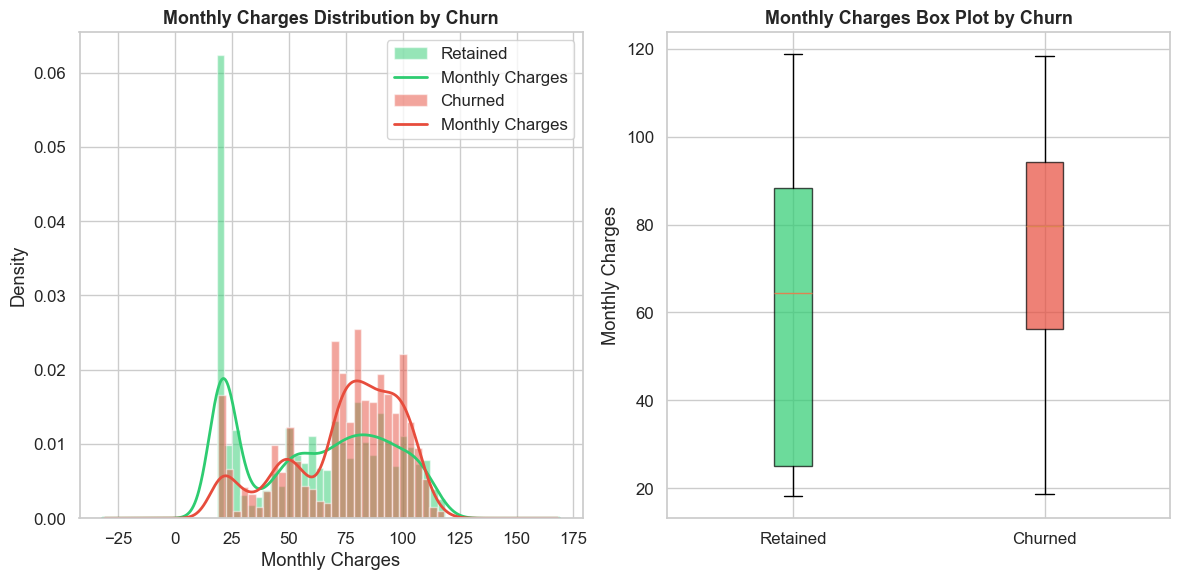

In [10]:
fig = plot_numerical_distribution(df, "Monthly Charges")
plt.show()

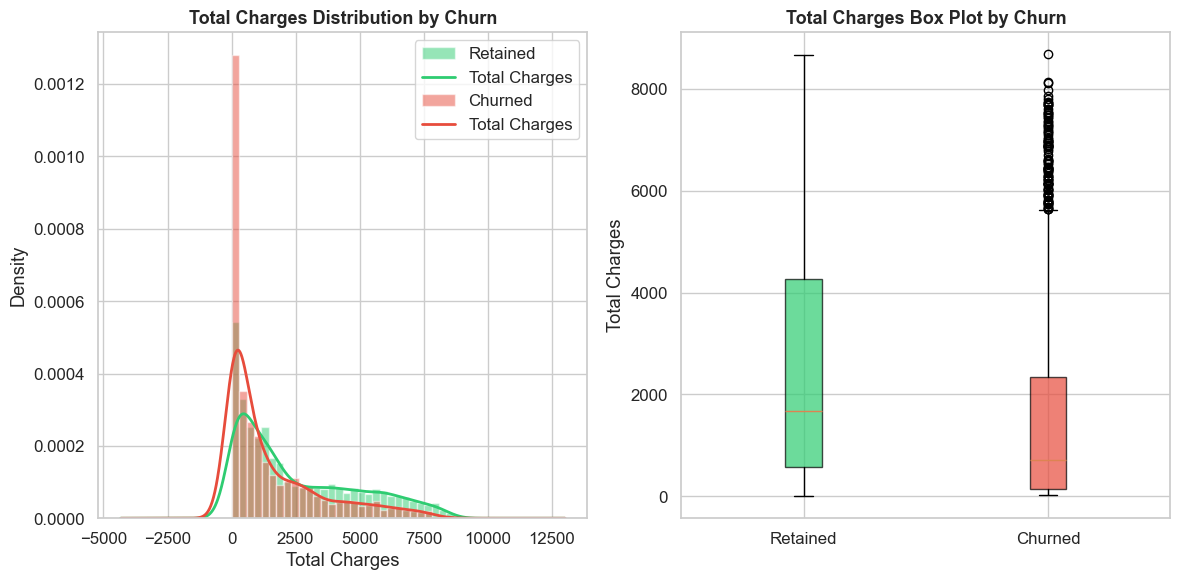

In [11]:
fig = plot_numerical_distribution(df, "Total Charges")
plt.show()

### Financial Findings

---
- **Monthly Charges**: Churned customers tend to have HIGHER monthly charges (median ~$80 vs ~$65).
  This suggests price sensitivity or that higher-cost plans need more value justification.
- **Total Charges**: Churned customers have LOWER total charges, reflecting their shorter tenure.

## Tenure Analysis

---
**Business Question**: When are customers most likely to leave?

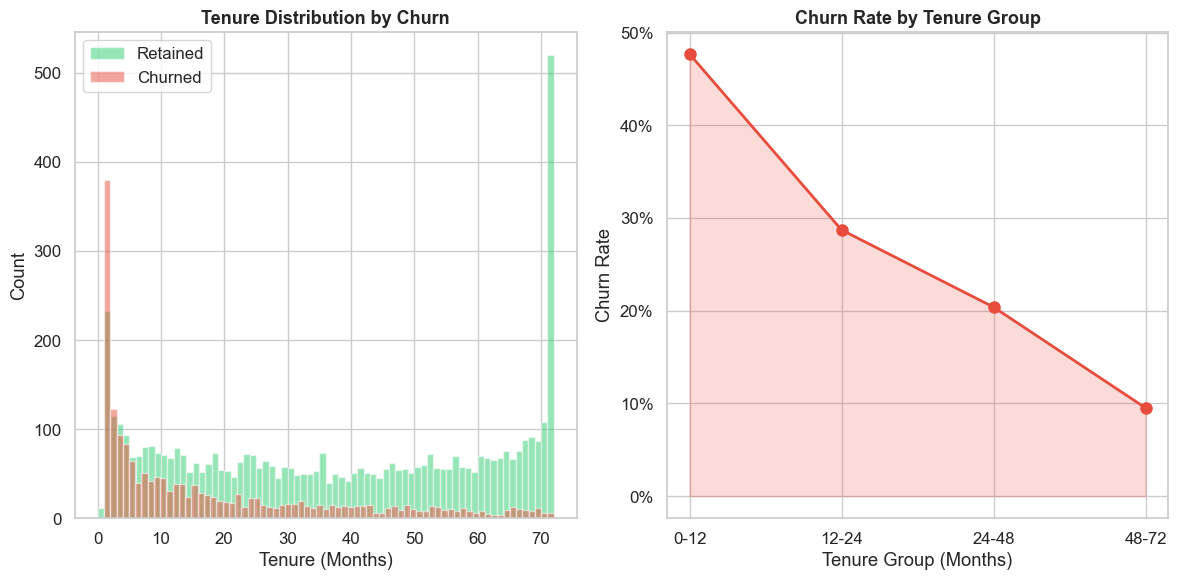

In [12]:
fig = plot_tenure_analysis(df)
plt.show()

### Tenure Findings

---
- The first 12 months are the **critical danger zone** (~50% of churners leave in year one).
- Churn rate decreases dramatically with tenure.
- Customers surviving past 48 months have very low churn rates.
- Implication: **Onboarding experience and first-year retention programs are essential.**

## Geographic Analysis

---
**Business Question**: Are there regional churn hotspots?

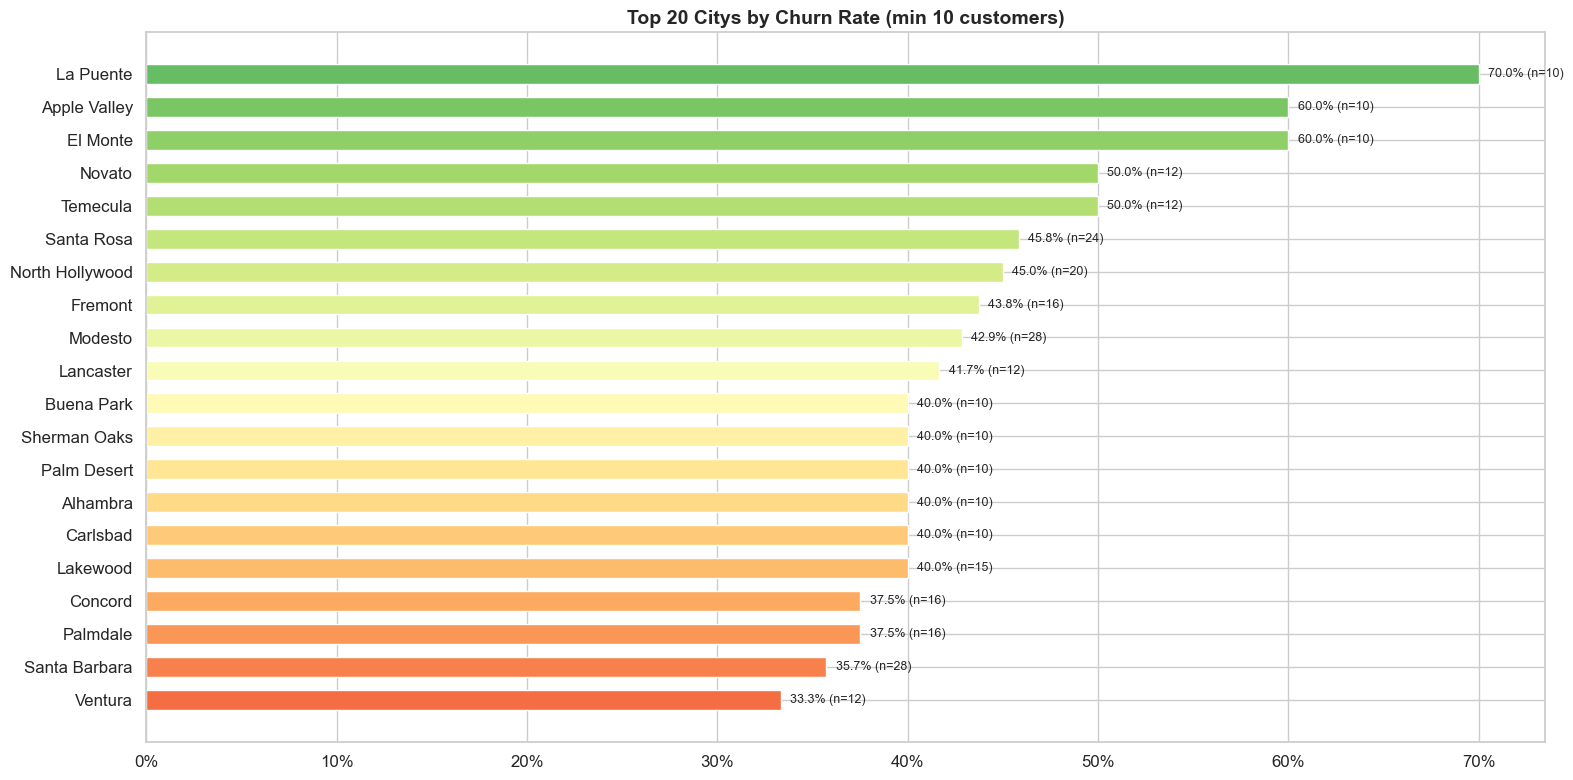

In [13]:
fig = plot_geographic_churn(df_raw, geo_col="City", top_n=20)
plt.show()

## Correlation Analysis

---

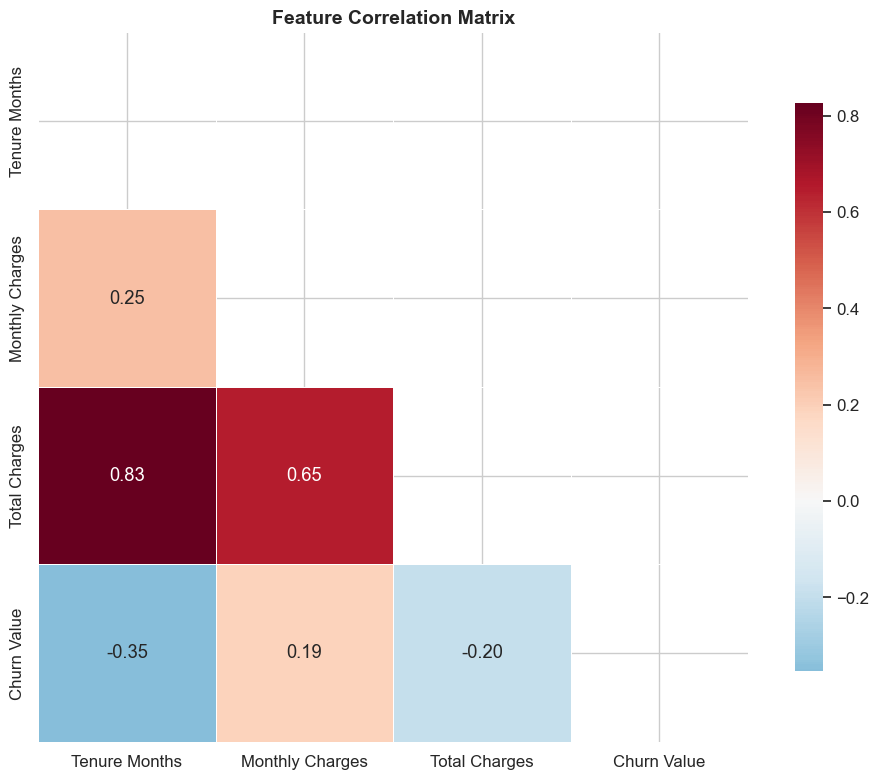

In [14]:
fig = plot_correlation_heatmap(df)
plt.show()

## EDA Summary

---
### Top Churn Drivers Identified

1. **Contract Type**: Month-to-month is the strongest single predictor
2. **Tenure**: New customers (<12 months) are most at risk
3. **Internet Service**: Fiber without security services = highest risk
4. **Payment Method**: Electronic check correlates with high churn
5. **Dependents**: Family customers are most stable
6. **Monthly Charges**: Higher charges increase churn risk

### Business Implications

1. **Retention Priority**: Focus on month-to-month fiber customers in their first year
2. **Service Bundling**: Encourage security/support service adoption
3. **Contract Migration**: Incentivize annual/bi-annual contract upgrades
4. **Onboarding**: Strengthen first-90-day customer experience
5. **Payment Transition**: Encourage auto-pay methods over electronic checks
